In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Calibo\e commerce\ecommerce_customer.csv")

In [3]:
df.head()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


In [4]:
df.tail()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
3050,ORD101148,C1685,2025-10-08,47.0,Premium,Delhi,East,Grocery,Novel,Mobile App,...,11.5,9,8,4.4,1111.95,313.24,798.71,646.78,151.93,19.02
3051,ORD102155,C1641,2025-09-15,27.0,Regular,Bengaluru,North,Home Appliances,Novel,Online,...,11.0,13,5,5.0,329.51,31.67,297.84,252.38,45.46,15.26
3052,ORD101767,C1457,2025-07-04,35.0,Premium,Bengaluru,East,Sports,Shirt,Store,...,9.5,6,4,3.1,20073.84,3894.32,16179.52,13306.36,2873.16,17.76
3053,ORD101123,C1789,2025-04-09,39.0,Occasional,Kochi,West,Sports,Shoes,Online,...,32.4,7,6,3.4,274.47,44.74,229.73,163.04,66.69,29.03
3054,ORD101347,C1040,2025-11-09,24.0,Regular,Kochi,Central,Home Appliances,Laptop,Marketplace,...,7.3,13,6,3.1,5554.28,525.99,5028.29,2927.82,2100.47,41.77


In [5]:
df.shape



(3055, 32)

In [6]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Age',
       'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name',
       'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Return_Status', 'Order_Status', 'Marketing_Source',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit',
       'Profit_Margin_Pct'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 3055 non-null   str    
 1   Customer_ID              3055 non-null   str    
 2   Order_Date               3055 non-null   str    
 3   Customer_Age             2932 non-null   float64
 4   Customer_Segment         3055 non-null   str    
 5   City                     2979 non-null   str    
 6   Region                   3055 non-null   str    
 7   Category                 3055 non-null   str    
 8   Product_Name             3055 non-null   str    
 9   Sales_Channel            3055 non-null   str    
 10  Payment_Method           2978 non-null   str    
 11  Device                   3055 non-null   str    
 12  Quantity                 3055 non-null   int64  
 13  Unit_Price               2962 non-null   float64
 14  Discount_Pct             2902 non-n

In [8]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,2932.000000,3055.000000,2962.00000,2902.000000,2948.000000,2840.000000,3055.000000,2930.000000,2979.000000,3055.000000,3055.000000,2901.000000,2962.000000,2810.000000,2810.000000,2810.000000,2810.000000,2809.000000
mean,35.328104,3.248773,1583.13266,15.407105,4.550543,3.745070,3.673355,872.558362,14.699094,7.062848,5.006219,3.669424,5171.610665,786.158598,4411.498904,3153.257843,1258.241060,28.377437
std,11.316398,1.861875,2366.58516,10.502571,2.288896,0.777563,0.838132,629.154614,9.540359,2.678465,2.276333,0.842385,8994.240302,1681.951220,7595.452348,5346.688134,2529.055858,9.427132
min,-13.000000,-2.000000,12.75000,-10.000000,-3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-7620.860000,-780.380000,-6840.480000,-5446.480000,-1394.000000,12.040000
25%,28.000000,2.000000,468.92250,8.250000,3.000000,3.200000,3.100000,363.000000,7.900000,5.000000,3.000000,3.100000,1214.615000,107.150000,1020.622500,723.547500,263.065000,20.280000
50%,35.000000,3.000000,923.14500,14.895000,4.000000,3.800000,3.700000,834.500000,12.700000,7.000000,5.000000,3.700000,2640.185000,327.825000,2286.520000,1613.435000,611.055000,28.230000
75%,42.250000,4.000000,1878.94250,21.670000,6.000000,4.300000,4.300000,1294.000000,19.450000,9.000000,6.000000,4.300000,5730.980000,834.957500,4841.167500,3504.470000,1318.835000,36.400000
max,102.000000,40.000000,61182.50000,120.000000,35.000000,9.000000,5.000000,2970.000000,96.100000,18.000000,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000


In [9]:
df['Payment_Method'] = np.where(
    df['Payment_Method'].notna(),
    df['Payment_Method'].str.strip().str.title(),
    df['Payment_Method']
)

In [10]:
df['Payment_Method'].value_counts()

Payment_Method
Upi            546
Net Banking    513
Credit Card    500
Debit Card     476
Wallet         474
Cash           469
Name: count, dtype: int64

In [11]:
df['Category'].value_counts()

Category
Home Appliances      428
Sports               389
Electronics          371
Grocery              371
Furniture            366
Beauty               365
Fashion              357
Books                348
 Books                10
 Home Appliances      10
 Sports                9
 Grocery               8
 Electronics           7
 Fashion               7
 Furniture             5
 Beauty                4
Name: count, dtype: int64

In [12]:
df['Category'] = np.where(
    df['Category'].notna(),
    df['Category'].str.strip().str.title(),
    df['Category']
)

In [13]:
df['Category'].value_counts()

Category
Home Appliances    438
Sports             398
Grocery            379
Electronics        378
Furniture          371
Beauty             369
Fashion            364
Books              358
Name: count, dtype: int64

In [14]:
df['City'].value_counts()

City
Chennai       308
Kochi         299
Delhi         296
Coimbatore    295
Kolkata       293
Mumbai        291
Hyderabad     290
Pune          281
Bengaluru     278
Jaipur        257
bengaluru      15
chennai        13
mumbai         11
pune           10
hyderabad       9
kochi           8
delhi           8
kolkata         8
coimbatore      7
jaipur          2
Name: count, dtype: int64

In [15]:
df['City'] = np.where(
    df['City'].notna(),
    df['City'].str.strip().str.title(),
    df['City']
)

In [16]:
df['City'].value_counts()

City
Chennai       321
Kochi         307
Delhi         304
Coimbatore    302
Mumbai        302
Kolkata       301
Hyderabad     299
Bengaluru     293
Pune          291
Jaipur        259
Name: count, dtype: int64

In [17]:
df.duplicated().sum()

np.int64(50)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()

Order_ID                     0
Customer_ID                  0
Order_Date                   0
Customer_Age               120
Customer_Segment             0
City                        75
Region                       0
Category                     0
Product_Name                 0
Sales_Channel                0
Payment_Method              75
Device                       0
Quantity                     0
Unit_Price                  90
Discount_Pct               151
Shipping_Days              105
Customer_Rating            209
Delivery_Rating              0
Return_Status                0
Order_Status                 0
Marketing_Source             0
Customer_Loyalty_Points    121
Website_Session_Minutes     75
Items_Viewed                 0
Previous_Orders              0
Customer_Satisfaction      151
Gross_Amount                90
Discount_Amount            240
Net_Sales                  240
Estimated_Cost             240
Profit                     240
Profit_Margin_Pct          241
dtype: i

In [21]:
df.isna().sum()[df.isna().sum() > 0]

Customer_Age               120
City                        75
Payment_Method              75
Unit_Price                  90
Discount_Pct               151
Shipping_Days              105
Customer_Rating            209
Customer_Loyalty_Points    121
Website_Session_Minutes     75
Customer_Satisfaction      151
Gross_Amount                90
Discount_Amount            240
Net_Sales                  240
Estimated_Cost             240
Profit                     240
Profit_Margin_Pct          241
dtype: int64

In [22]:
df.dtypes

Order_ID                       str
Customer_ID                    str
Order_Date                     str
Customer_Age               float64
Customer_Segment               str
City                           str
Region                         str
Category                       str
Product_Name                   str
Sales_Channel                  str
Payment_Method                 str
Device                         str
Quantity                     int64
Unit_Price                 float64
Discount_Pct               float64
Shipping_Days              float64
Customer_Rating            float64
Delivery_Rating            float64
Return_Status                  str
Order_Status                   str
Marketing_Source               str
Customer_Loyalty_Points    float64
Website_Session_Minutes    float64
Items_Viewed                 int64
Previous_Orders              int64
Customer_Satisfaction      float64
Gross_Amount               float64
Discount_Amount            float64
Net_Sales           

In [23]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Age',
       'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name',
       'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Return_Status', 'Order_Status', 'Marketing_Source',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit',
       'Profit_Margin_Pct'],
      dtype='str')

In [24]:
X = df.drop('Return_Status', axis=1)
y = df['Return_Status']

In [25]:
X.head()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


In [26]:
y.head()

0    No
1    No
2    No
3    No
4    No
Name: Return_Status, dtype: str

In [27]:
numeric_columns = X.select_dtypes(include=np.number).columns

numeric_columns

Index(['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct',
       'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit',
       'Profit_Margin_Pct'],
      dtype='str')

In [28]:
categorical_columns = X.select_dtypes(include='object').columns

categorical_columns

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\1904574067.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Segment', 'City',
       'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method',
       'Device', 'Order_Status', 'Marketing_Source'],
      dtype='str')

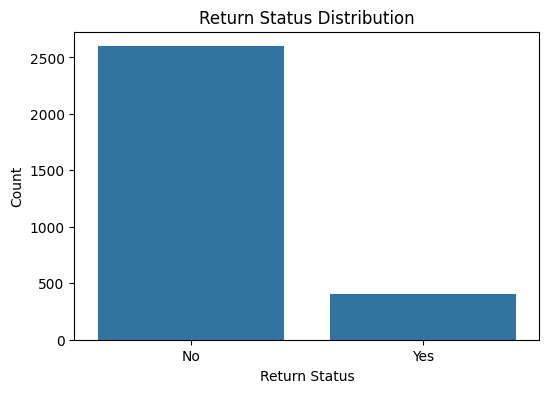

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df['Return_Status'])

plt.title('Return Status Distribution')
plt.xlabel('Return Status')
plt.ylabel('Count')

plt.show()

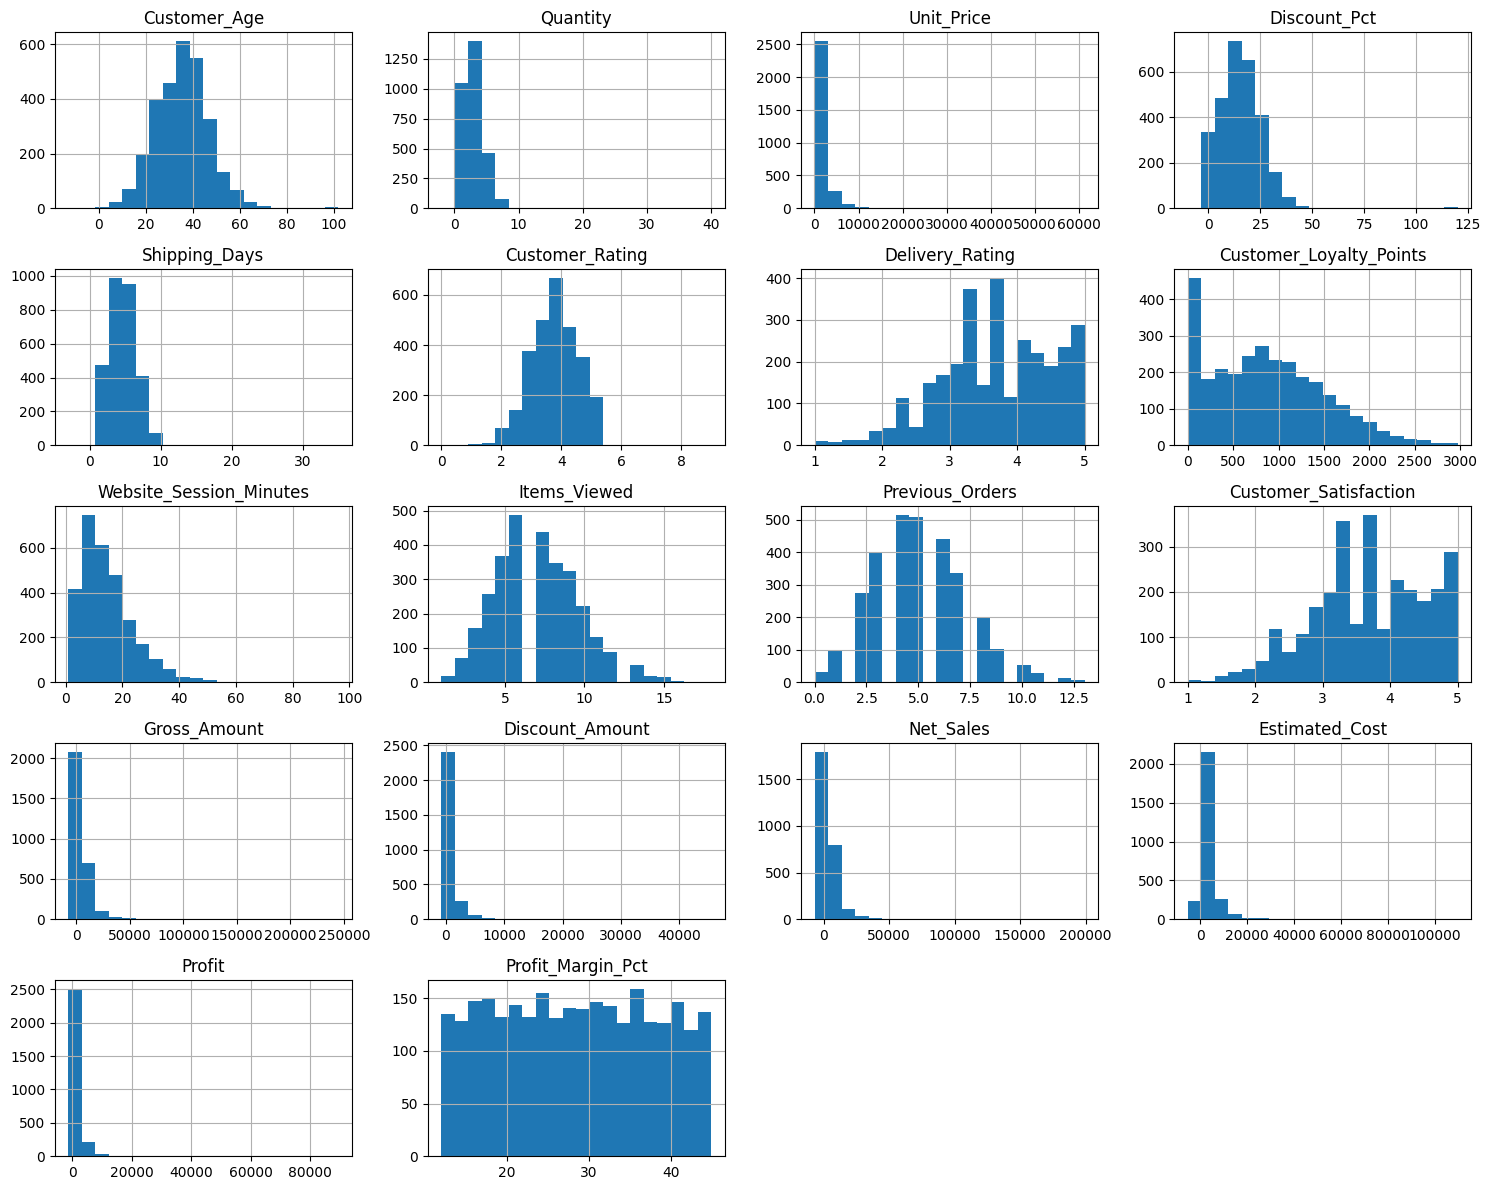

In [30]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

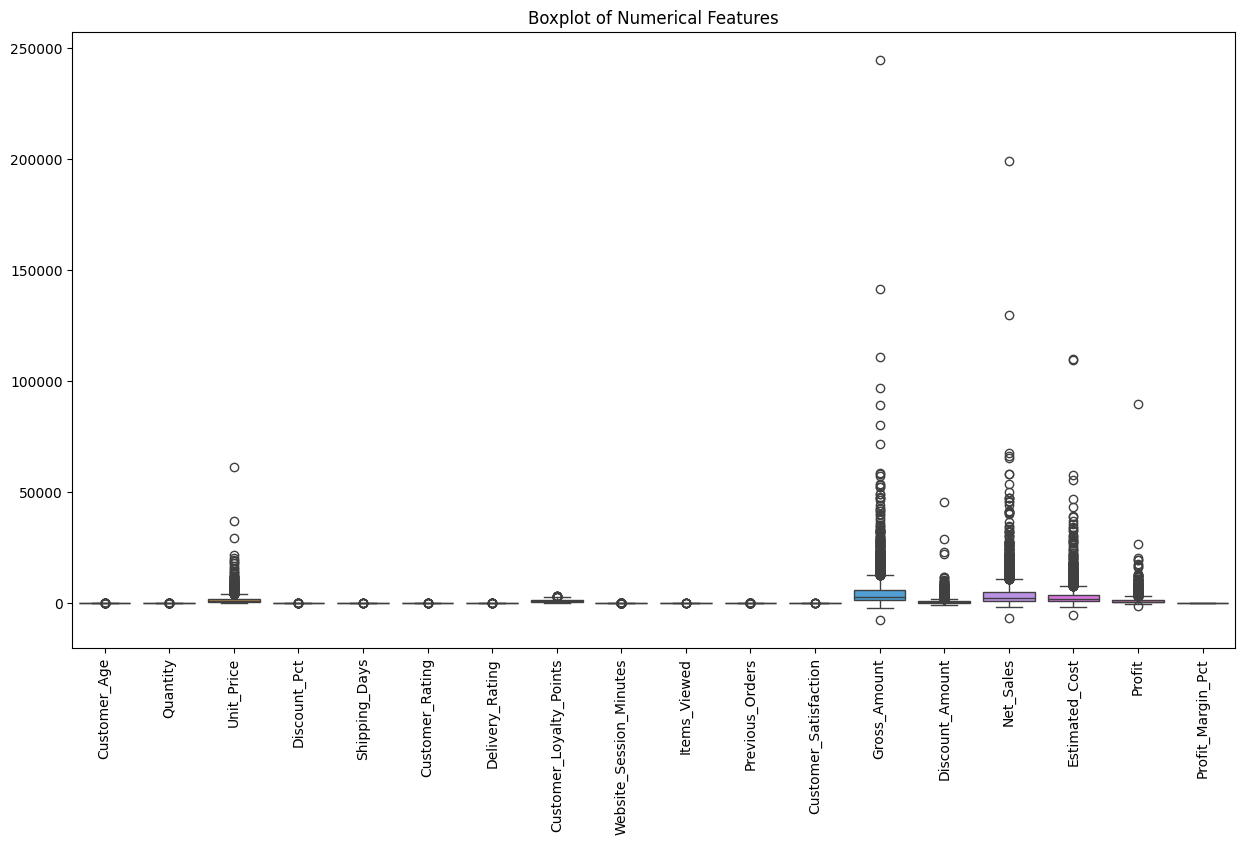

In [31]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=90)
plt.title('Boxplot of Numerical Features')

plt.show()

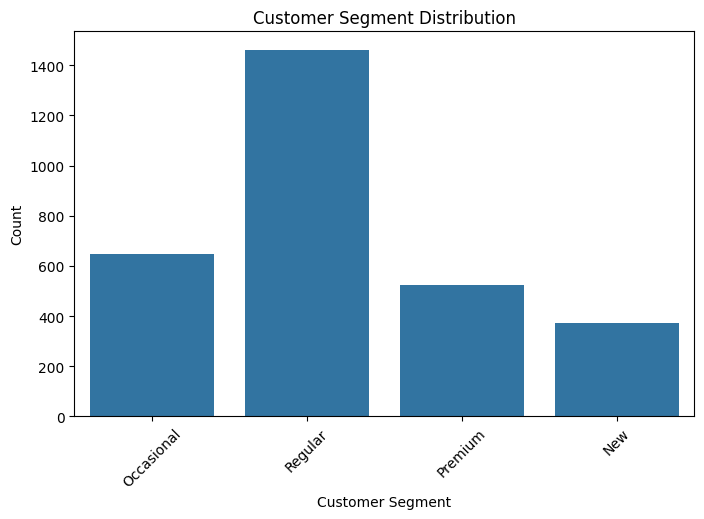

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Customer_Segment'
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

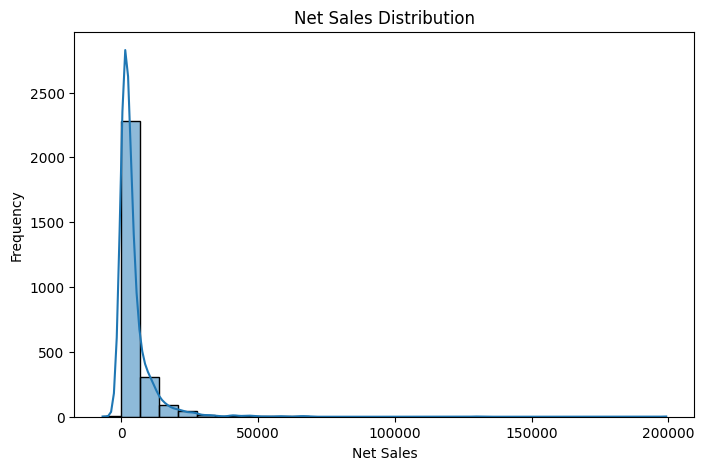

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Net_Sales'],
    bins=30,
    kde=True
)

plt.title("Net Sales Distribution")
plt.xlabel("Net Sales")
plt.ylabel("Frequency")

plt.show()

In [34]:
correlation = df[numeric_columns].corr()
correlation

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
Customer_Age,1.000000,-0.009603,-0.005537,0.021514,0.011064,-0.020332,-0.005838,0.024776,-0.005101,-0.011607,-0.009768,-0.008859,-0.002463,-0.011148,0.001058,0.000267,0.002613,-0.003362
Quantity,-0.009603,1.000000,0.005627,0.018052,-0.011264,-0.000889,-0.011621,0.003779,0.006173,-0.017558,0.003623,0.041823,0.326892,0.294361,0.329981,0.343572,0.264654,-0.009931
Unit_Price,-0.005537,0.005627,1.000000,-0.014119,-0.019047,-0.007195,0.025751,-0.004169,0.004952,0.005976,-0.022717,-0.010163,0.869996,0.725464,0.858656,0.829051,0.826038,0.004419
Discount_Pct,0.021514,0.018052,-0.014119,1.000000,-0.008679,0.025412,0.017986,-0.012707,0.001972,-0.007474,0.008713,0.014984,-0.012121,0.273965,-0.074884,-0.072163,-0.072334,-0.014710
Shipping_Days,0.011064,-0.011264,-0.019047,-0.008679,1.000000,0.010802,0.026259,0.022385,0.005347,0.001233,0.002679,0.009234,-0.025018,-0.031463,-0.025912,-0.022497,-0.030249,-0.038008
Customer_Rating,-0.020332,-0.000889,-0.007195,0.025412,0.010802,1.000000,0.022974,0.005967,0.001972,-0.004109,0.011797,-0.002543,-0.008085,0.010720,-0.010695,-0.014098,-0.002920,0.000773
Delivery_Rating,-0.005838,-0.011621,0.025751,0.017986,0.026259,0.022974,1.000000,0.009248,0.002646,0.015583,-0.022665,-0.011683,0.013611,0.009545,0.015465,0.013828,0.017214,-0.025493
Customer_Loyalty_Points,0.024776,0.003779,-0.004169,-0.012707,0.022385,0.005967,0.009248,1.000000,0.052564,-0.005094,0.004761,-0.007747,-0.004421,-0.010284,-0.005888,-0.005166,-0.006765,0.003820
Website_Session_Minutes,-0.005101,0.006173,0.004952,0.001972,0.005347,0.001972,0.002646,0.052564,1.000000,0.027495,0.002047,0.026534,0.003059,0.005541,0.005435,0.009767,-0.004309,-0.021794
Items_Viewed,-0.011607,-0.017558,0.005976,-0.007474,0.001233,-0.004109,0.015583,-0.005094,0.027495,1.000000,-0.018599,-0.016323,0.014523,0.031207,0.019050,0.013602,0.028456,-0.015143


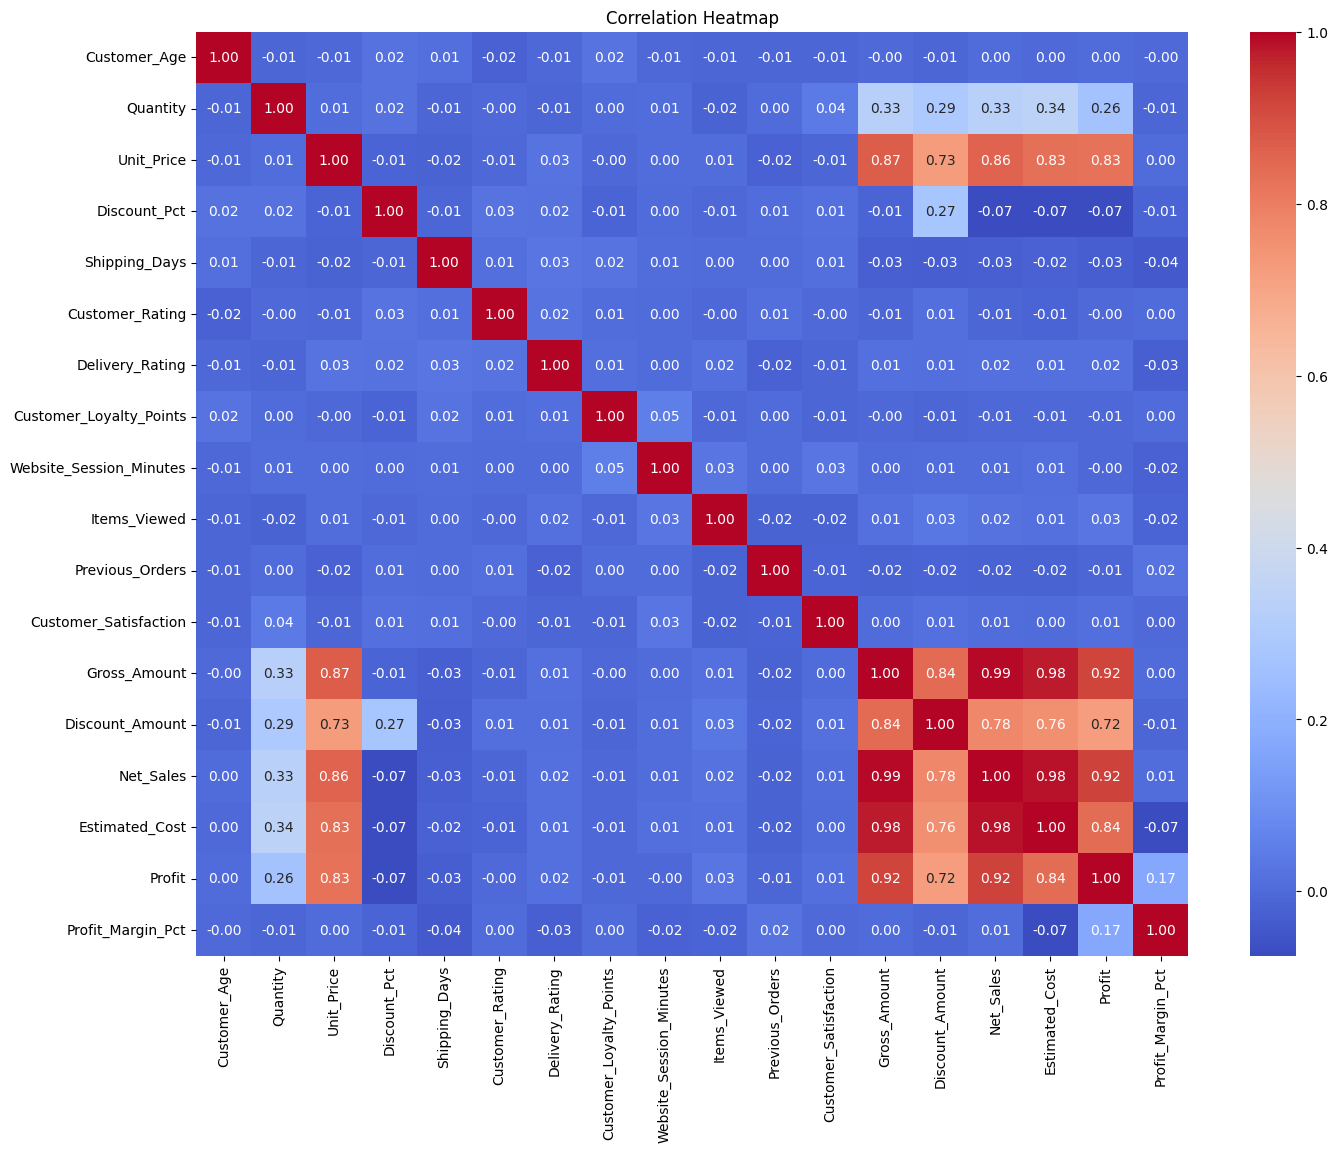

In [35]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
numeric_columns = X.select_dtypes(include=np.number).columns

categorical_columns = X.select_dtypes(include='object').columns

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\1661335.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [37]:
for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

In [38]:
for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

In [39]:
X.isnull().sum().sum()

np.int64(0)

In [40]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [41]:
X['Order_Date'] = pd.to_datetime(X['Order_Date'], errors='coerce')

In [42]:
X['Order_Year'] = X['Order_Date'].dt.year
X['Order_Month'] = X['Order_Date'].dt.month
X['Order_Day'] = X['Order_Date'].dt.day

In [43]:
X = X.drop('Order_Date', axis=1)

In [44]:
X = pd.get_dummies(X, drop_first=True)

In [45]:
X.head()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,...,Device_Mobile,Device_Tablet,Order_Status_Delayed,Order_Status_Delivered,Order_Status_Pending,Order_Status_Returned,Marketing_Source_Google Ads,Marketing_Source_Organic,Marketing_Source_Referral,Marketing_Source_Social Media
0,44.0,2,361.67,0.00,6.0,2.9,5.0,1062.0,16.4,10,...,False,False,False,True,False,False,False,False,False,True
1,51.0,2,922.38,28.01,5.0,2.5,3.6,1252.0,23.2,9,...,False,False,False,False,True,False,False,True,False,False
2,35.0,1,739.05,14.30,7.0,3.9,3.7,0.0,9.1,10,...,False,False,False,False,True,False,False,False,True,False
3,38.0,4,7001.11,5.26,4.0,3.5,3.5,1388.0,22.7,4,...,False,False,False,False,False,True,False,False,False,True
4,39.0,2,4920.89,18.72,4.0,5.0,4.6,1132.0,6.6,8,...,False,False,False,True,False,False,False,False,False,True


In [46]:
X.dtypes

Customer_Age                     float64
Quantity                           int64
Unit_Price                       float64
Discount_Pct                     float64
Shipping_Days                    float64
                                  ...   
Order_Status_Returned               bool
Marketing_Source_Google Ads         bool
Marketing_Source_Organic            bool
Marketing_Source_Referral           bool
Marketing_Source_Social Media       bool
Length: 72, dtype: object

In [47]:
y.unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [48]:
y.value_counts()

Return_Status
No     2598
Yes     407
Name: count, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=34,
    stratify=y
)

In [50]:
X_train.shape, X_test.shape

((2404, 72), (601, 72))

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [52]:
X_train_scaled = scaler.fit_transform(X_train)

In [53]:
X_test_scaled = scaler.transform(X_test)

In [54]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

In [55]:
numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(include='object').columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [56]:
print(X.isnull().sum())

Customer_Age                     0
Quantity                         0
Unit_Price                       0
Discount_Pct                     0
Shipping_Days                    0
                                ..
Order_Status_Returned            0
Marketing_Source_Google Ads      0
Marketing_Source_Organic         0
Marketing_Source_Referral        0
Marketing_Source_Social Media    0
Length: 72, dtype: int64


Linear Regression

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [58]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [59]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [60]:
numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(include='object').columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\2933309678.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [61]:
X['Order_Date'] = pd.to_datetime(X['Order_Date'], errors='coerce')

X['Order_Year'] = X['Order_Date'].dt.year
X['Order_Month'] = X['Order_Date'].dt.month
X['Order_Day'] = X['Order_Date'].dt.day

X = X.drop('Order_Date', axis=1)

In [62]:
X = pd.get_dummies(X, drop_first=True)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=34
)

In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
print("Missing values in Profit:", df['Profit'].isnull().sum())

Missing values in Profit: 240


In [66]:
df = df.dropna(subset=['Profit'])

print("Missing values in Profit:", df['Profit'].isnull().sum())

Missing values in Profit: 0


In [67]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [68]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [69]:
import numpy as np

numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(include='object').columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\2734208529.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [70]:
X['Order_Date'] = pd.to_datetime(X['Order_Date'], errors='coerce')

X['Order_Year'] = X['Order_Date'].dt.year
X['Order_Month'] = X['Order_Date'].dt.month
X['Order_Day'] = X['Order_Date'].dt.day

X = X.drop('Order_Date', axis=1)

In [71]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [72]:
X = pd.get_dummies(X, drop_first=True)

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=34
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [76]:
y_pred = model.predict(X_test_scaled)

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 5.1395793595357923e-23
Mean Absolute Error: 5.6465726207685626e-12
R2 Score: 1.0


Logistic Regression

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [79]:
X = df.drop('Return_Status', axis=1)
y = df['Return_Status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2765, 31)
y shape: (2765,)


In [80]:
print(y.value_counts())
print(y.unique())

Return_Status
No     2385
Yes     380
Name: count, dtype: int64
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [81]:
df = df.dropna(subset=['Return_Status'])

X = df.drop('Return_Status', axis=1)
y = df['Return_Status']

print("Missing values in y:", y.isnull().sum())

Missing values in y: 0


In [82]:
X = X.drop(
    ['Order_ID', 'Customer_ID'],
    axis=1,
    errors='ignore'
)

In [83]:
numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(include='object').columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\2933309678.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [84]:
print("Missing values in X:", X.isnull().sum().sum())

Missing values in X: 0


In [85]:
X['Order_Date'] = pd.to_datetime(
    X['Order_Date'],
    errors='coerce'
)

X['Order_Year'] = X['Order_Date'].dt.year
X['Order_Month'] = X['Order_Date'].dt.month
X['Order_Day'] = X['Order_Date'].dt.day

X = X.drop('Order_Date', axis=1)

In [86]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("X shape after encoding:", X.shape)

X shape after encoding: (2765, 72)


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=34,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2212, 72)
X_test: (553, 72)
y_train: (2212,)
y_test: (553,)


In [88]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


In [89]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [90]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No']


In [91]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8589511754068716
Precision: 0.7435929413231901
Recall   : 0.8589511754068716
F1 Score : 0.7971200596674665


In [92]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[475   2]
 [ 76   0]]


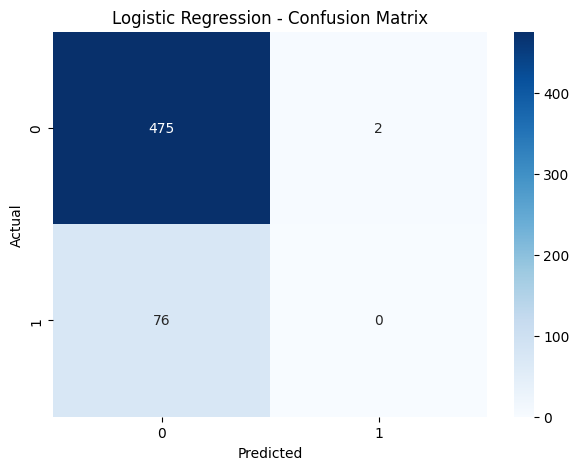

In [93]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [94]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.86      1.00      0.92       477
         Yes       0.00      0.00      0.00        76

    accuracy                           0.86       553
   macro avg       0.43      0.50      0.46       553
weighted avg       0.74      0.86      0.80       553



In [95]:
y_prob = model.predict_proba(X_test_scaled)

In [96]:
y_prob_positive = y_prob[:, 1]

In [97]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=model.classes_[1]
)

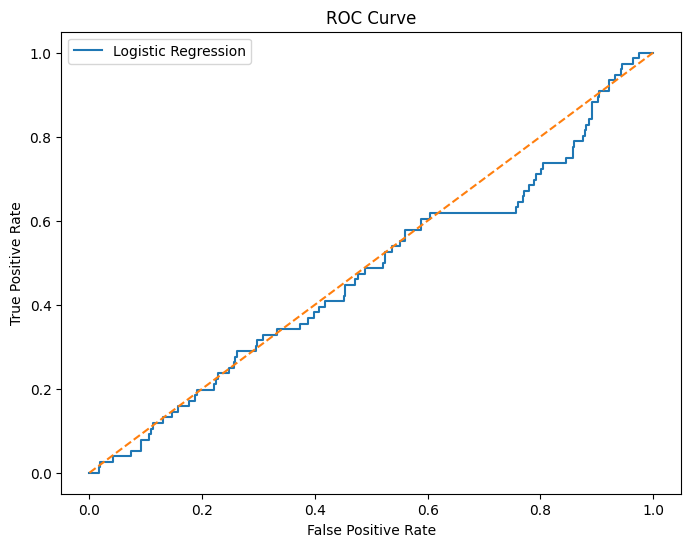

In [98]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [99]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.474153150171025


In [100]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print(results)

      Metric     Score
0   Accuracy  0.858951
1  Precision  0.743593
2     Recall  0.858951
3   F1 Score  0.797120
4    ROC-AUC  0.474153


KNN

In [101]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully")

KNN model trained successfully


In [103]:
y_pred = knn_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:10])

Predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes']


In [104]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)




Accuracy: 0.8553345388788427
Precision: 0.7878353131587624
Recall: 0.8553345388788427
F1 Score: 0.80450372671883


In [105]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[470   7]
 [ 73   3]]


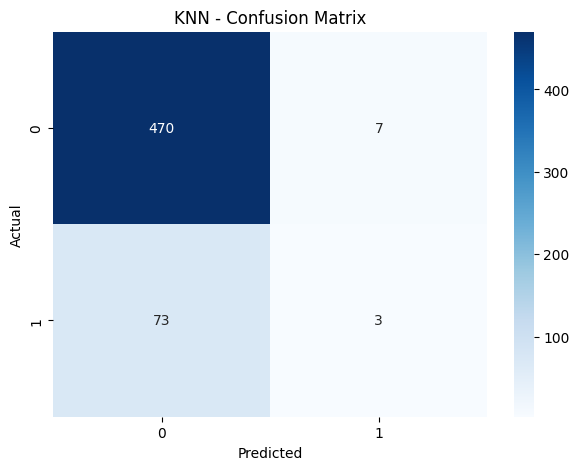

In [106]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")

plt.show()

In [107]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.99      0.92       477
         Yes       0.30      0.04      0.07        76

    accuracy                           0.86       553
   macro avg       0.58      0.51      0.50       553
weighted avg       0.79      0.86      0.80       553



In [108]:
y_prob = knn_model.predict_proba(X_test_scaled)
y_prob_positive = y_prob[:, 1]

print(y_prob[:5])

[[1.  0. ]
 [0.6 0.4]
 [0.6 0.4]
 [0.8 0.2]
 [0.6 0.4]]


In [109]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=knn_model.classes_[1]
)


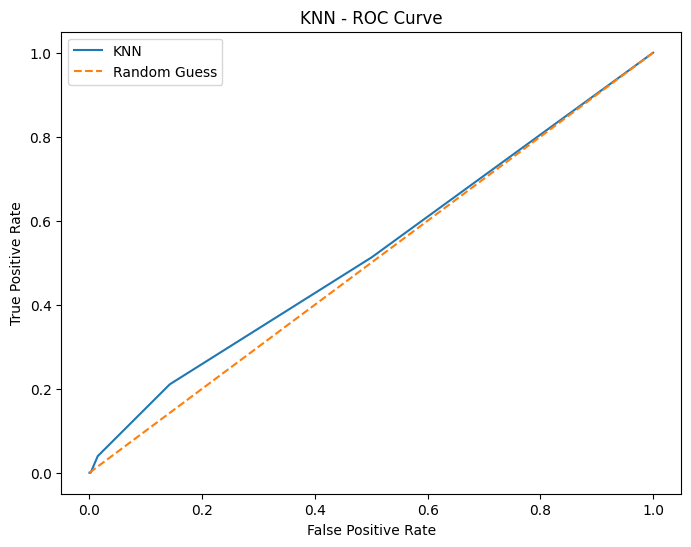

In [110]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label='KNN'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN - ROC Curve")

plt.legend()
plt.show()

In [111]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5234469822354628


In [112]:
print("===== KNN CLASSIFICATION RESULTS =====")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

===== KNN CLASSIFICATION RESULTS =====
Accuracy : 0.8553345388788427
Precision: 0.7878353131587624
Recall   : 0.8553345388788427
F1 Score : 0.80450372671883
ROC-AUC  : 0.5234469822354628


Decision Tree Classifier

In [113]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
dt_model = DecisionTreeClassifier(
    random_state=34
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


In [115]:
y_pred = dt_model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
['Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No']


In [116]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)


f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)

Accuracy: 0.786618444846293
Precision: 0.786618444846293
Recall: 0.786618444846293
F1 Score: 0.786618444846293


In [117]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[418  59]
 [ 59  17]]


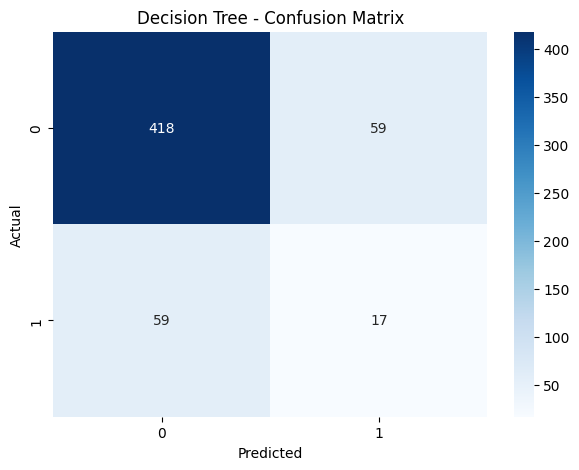

In [118]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [119]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.88      0.88       477
         Yes       0.22      0.22      0.22        76

    accuracy                           0.79       553
   macro avg       0.55      0.55      0.55       553
weighted avg       0.79      0.79      0.79       553



In [120]:
y_prob = dt_model.predict_proba(
    X_test
)

print(y_prob[:5])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [121]:
y_prob_positive = y_prob[:, 1]

In [122]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=dt_model.classes_[1]
)

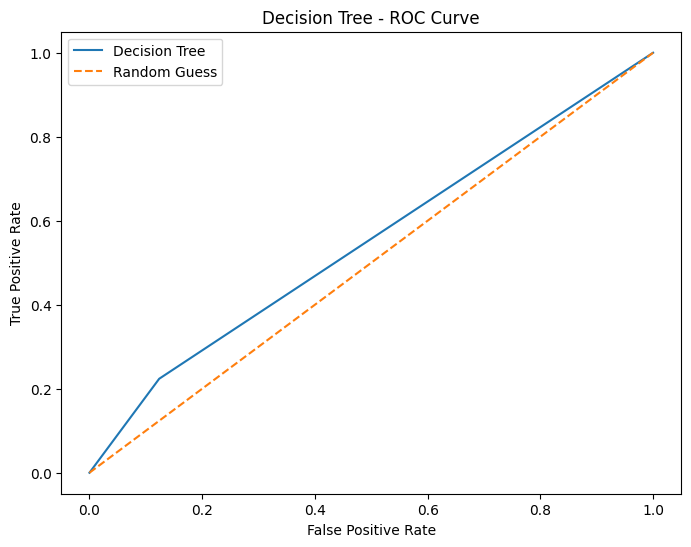

In [123]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label='Decision Tree'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")

plt.legend()
plt.show()

In [124]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5499972415315016


In [125]:
print("===== DECISION TREE CLASSIFICATION RESULTS =====")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

===== DECISION TREE CLASSIFICATION RESULTS =====
Accuracy : 0.786618444846293
Precision: 0.786618444846293
Recall   : 0.786618444846293
F1 Score : 0.786618444846293
ROC-AUC  : 0.5499972415315016


Decision Tree Regession

In [126]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [127]:
df = df.dropna(subset=['Profit'])

In [128]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [129]:
X = X.drop(
    ['Order_ID', 'Customer_ID'],
    axis=1,
    errors='ignore'
)

In [130]:
print(X.select_dtypes(include='object').columns)

Index(['Order_Date', 'Customer_Segment', 'City', 'Region', 'Category',
       'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device',
       'Return_Status', 'Order_Status', 'Marketing_Source'],
      dtype='str')


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_21712\288157404.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include='object').columns)


In [131]:
X = pd.get_dummies(X, drop_first=True)

In [132]:
print(X.dtypes.value_counts())

bool       416
float64     14
int64        3
Name: count, dtype: int64


In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=34
)

In [134]:
from sklearn.tree import DecisionTreeRegressor

dt_reg_model = DecisionTreeRegressor(
    random_state=34
)

dt_reg_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",34
,"max_l

In [135]:
y_pred = dt_reg_model.predict(X_test)

In [136]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

Mean Squared Error : 478387.0236188067
Mean Absolute Error: 144.93403254972876
R2 Score           : 0.8952049630571562


Support Vector Classification

In [137]:
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
X = df.drop('Return_Status', axis=1)
y = df['Return_Status']

In [139]:
df_class = df.dropna(subset=['Return_Status']).copy()

In [140]:
# Remove ID columns
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [141]:
if 'Order_Date' in X.columns:
    X['Order_Date'] = pd.to_datetime(X['Order_Date'], errors='coerce')
    X['Order_Year'] = X['Order_Date'].dt.year
    X['Order_Month'] = X['Order_Date'].dt.month
    X['Order_Day'] = X['Order_Date'].dt.day
    X = X.drop('Order_Date', axis=1)

In [142]:
X = pd.get_dummies(X, drop_first=True)

In [143]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=34,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Classes:", y_train.unique())

X_train shape: (2212, 72)
y_train shape: (2212,)
Classes: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [146]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=34
)

svc_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [147]:
y_pred = svc_model.predict(X_test_scaled)

In [148]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred, average='weighted'
)

recall = recall_score(
    y_test, y_pred, average='weighted'
)

f1 = f1_score(
    y_test, y_pred, average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8625678119349005
Precision: 0.7440232301861619
Recall   : 0.8625678119349005
F1 Score : 0.7989220316367913


c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [149]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[477   0]
 [ 76   0]]


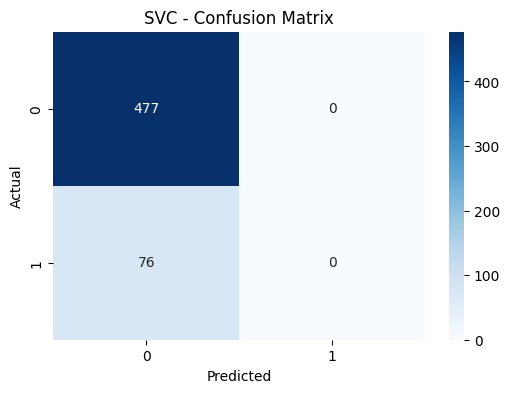

In [150]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC - Confusion Matrix")
plt.show()

In [151]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.86      1.00      0.93       477
         Yes       0.00      0.00      0.00        76

    accuracy                           0.86       553
   macro avg       0.43      0.50      0.46       553
weighted avg       0.74      0.86      0.80       553



c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [152]:
y_prob = svc_model.predict_proba(X_test_scaled)

y_prob_positive = y_prob[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=svc_model.classes_[1]
)

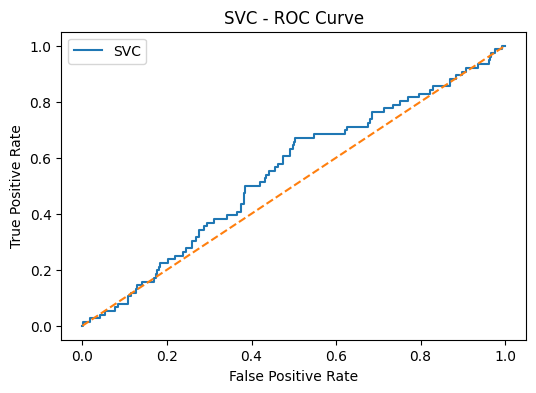

In [153]:
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label='SVC'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVC - ROC Curve")
plt.legend()
plt.show()

In [154]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.5442734193975505


Support Vector Regression

In [155]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [156]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [157]:
print(X_train.isna().sum().sort_values(ascending=False).head(20))

Customer_Age               0
Quantity                   0
Unit_Price                 0
Discount_Pct               0
Shipping_Days              0
Customer_Rating            0
Delivery_Rating            0
Customer_Loyalty_Points    0
Website_Session_Minutes    0
Items_Viewed               0
Previous_Orders            0
Customer_Satisfaction      0
Gross_Amount               0
Discount_Amount            0
Net_Sales                  0
Estimated_Cost             0
Profit                     0
Profit_Margin_Pct          0
Order_Year                 0
Order_Month                0
dtype: int64


In [158]:
import numpy as np

print("NaN values:", np.isnan(X_train_scaled).sum())

NaN values: 0


In [159]:

df = df.dropna(subset=['Profit'])

X = df.drop('Profit', axis=1)
y = df['Profit']

X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')


X = pd.get_dummies(X, drop_first=True)

X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=34
)

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:
print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [163]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1
)

svr_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = svr_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

Mean Squared Error : 4137398.9643808017
Mean Absolute Error: 875.1123432695856
R2 Score           : 0.09366505378904544


Random Forest Classification

In [165]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
df_class = df.dropna(subset=['Return_Status']).copy()

In [167]:
X = df_class.drop('Return_Status', axis=1)
y = df_class['Return_Status']

In [168]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [169]:
if 'Order_Date' in X.columns:
    X['Order_Date'] = pd.to_datetime(X['Order_Date'], errors='coerce')
    X['Order_Year'] = X['Order_Date'].dt.year
    X['Order_Month'] = X['Order_Date'].dt.month
    X['Order_Day'] = X['Order_Date'].dt.day
    X = X.drop('Order_Date', axis=1)

In [170]:

X = pd.get_dummies(X, drop_first=True)

In [171]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=34,
    stratify=y
)

print("Target values:")
print(y_train.unique())

Target values:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [173]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=34
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [174]:
y_pred = rf_model.predict(X_test)

In [175]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8625678119349005
Precision: 0.7440232301861619
Recall   : 0.8625678119349005
F1 Score : 0.7989220316367913


c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [176]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[477   0]
 [ 76   0]]


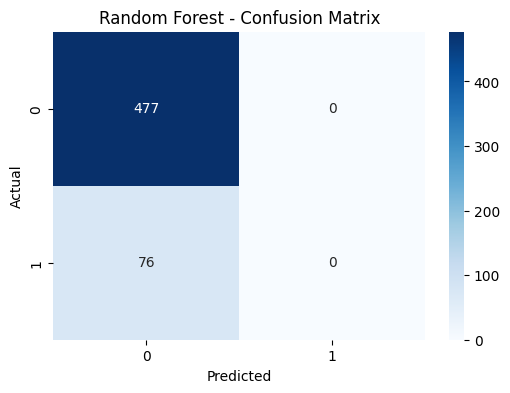

In [177]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [178]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.86      1.00      0.93       477
         Yes       0.00      0.00      0.00        76

    accuracy                           0.86       553
   macro avg       0.43      0.50      0.46       553
weighted avg       0.74      0.86      0.80       553



c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [179]:
y_prob = rf_model.predict_proba(X_test)

y_prob_positive = y_prob[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=rf_model.classes_[1]
)

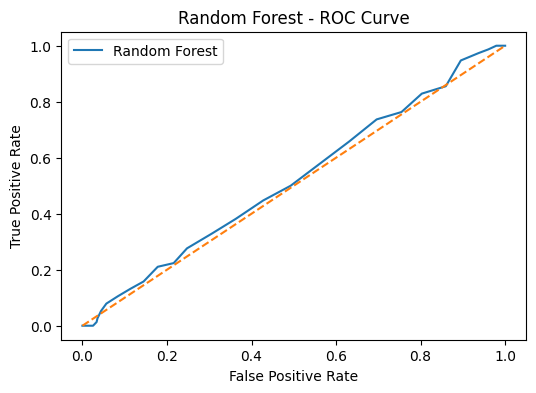

In [180]:
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label='Random Forest'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()
plt.show()

In [181]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.5198333885027032


Random Forest Regression

In [182]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [183]:
df = df.dropna(subset=['Profit'])

In [184]:
X = df.drop('Profit', axis=1)
y = df['Profit']


In [185]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [186]:
X = pd.get_dummies(X, drop_first=True)

In [187]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [188]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=34
)

In [189]:
from sklearn.ensemble import RandomForestRegressor

rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=34
)

rf_reg_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [190]:
y_pred = rf_reg_model.predict(X_test)

In [191]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

Mean Squared Error : 161374.30168913712
Mean Absolute Error: 81.55563833634716
R2 Score           : 0.9646494886520707


Bagging Classification

In [192]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [193]:
df_class = df.dropna(subset=['Return_Status']).copy()

In [194]:
X = df_class.drop('Return_Status', axis=1)
y = df_class['Return_Status']

In [195]:
X = X.drop(['Order_ID', 'Customer_ID'], axis=1, errors='ignore')

In [196]:
X = pd.get_dummies(X, drop_first=True)

In [197]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=34,
    stratify=y
)

In [199]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=34
)

bagging_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",34
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [200]:
y_pred = bagging_model.predict(X_test)

In [201]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.8481012658227848
Precision: 0.757171830197916
Recall   : 0.8481012658227848
F1 Score : 0.7947289130547714


In [202]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[468   9]
 [ 75   1]]


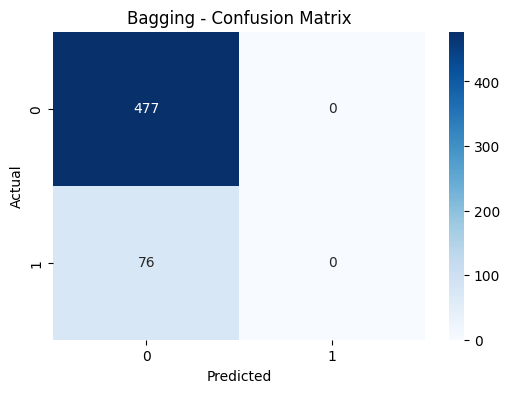

In [203]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging - Confusion Matrix")

plt.show()

In [204]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.98      0.92       477
         Yes       0.10      0.01      0.02        76

    accuracy                           0.85       553
   macro avg       0.48      0.50      0.47       553
weighted avg       0.76      0.85      0.79       553



In [205]:
y_prob = bagging_model.predict_proba(X_test)

y_prob_positive = y_prob[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=bagging_model.classes_[1]
)

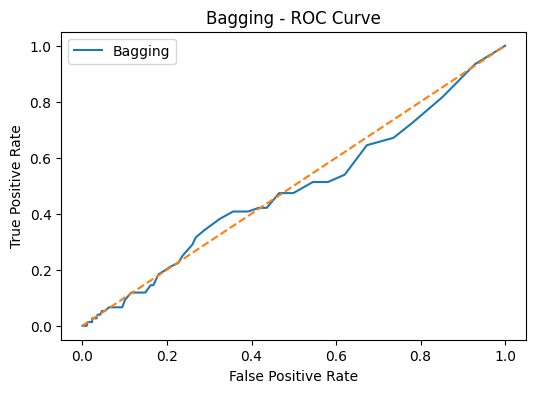

In [206]:
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label='Bagging'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Bagging - ROC Curve")

plt.legend()
plt.show()

In [207]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.4862352421935342


Gradient Boosting

In [208]:
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
# Check missing values
print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_test :", X_test.isna().sum().sum())

NaN in X_train: 0
NaN in X_test : 0


In [210]:
# Fill missing numerical values using training-set medians
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# Check again
print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_test :", X_test.isna().sum().sum())

NaN in X_train: 0
NaN in X_test : 0


In [211]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=34
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

In [212]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8481012658227848
Precision: 0.7422831262338868
Recall   : 0.8481012658227848
F1 Score : 0.7916718273923059

Confusion Matrix:
[[469   8]
 [ 76   0]]

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.98      0.92       477
         Yes       0.00      0.00      0.00        76

    accuracy                           0.85       553
   macro avg       0.43      0.49      0.46       553
weighted avg       0.74      0.85      0.79       553



In [213]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[469   8]
 [ 76   0]]


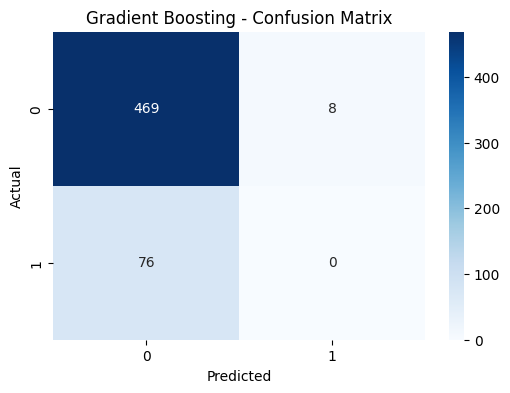

In [214]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting - Confusion Matrix")

plt.show()

In [215]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.98      0.92       477
         Yes       0.00      0.00      0.00        76

    accuracy                           0.85       553
   macro avg       0.43      0.49      0.46       553
weighted avg       0.74      0.85      0.79       553



In [216]:
y_prob = gb_model.predict_proba(X_test)

y_prob_positive = y_prob[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_positive,
    pos_label=gb_model.classes_[1]
)

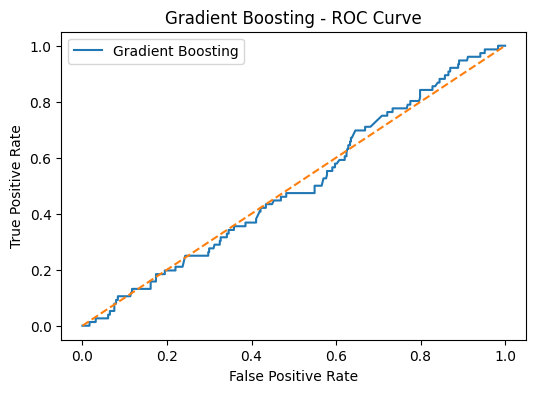

In [217]:
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label='Gradient Boosting'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting - ROC Curve")

plt.legend()
plt.show()

In [218]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_positive
)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.49904832836809
